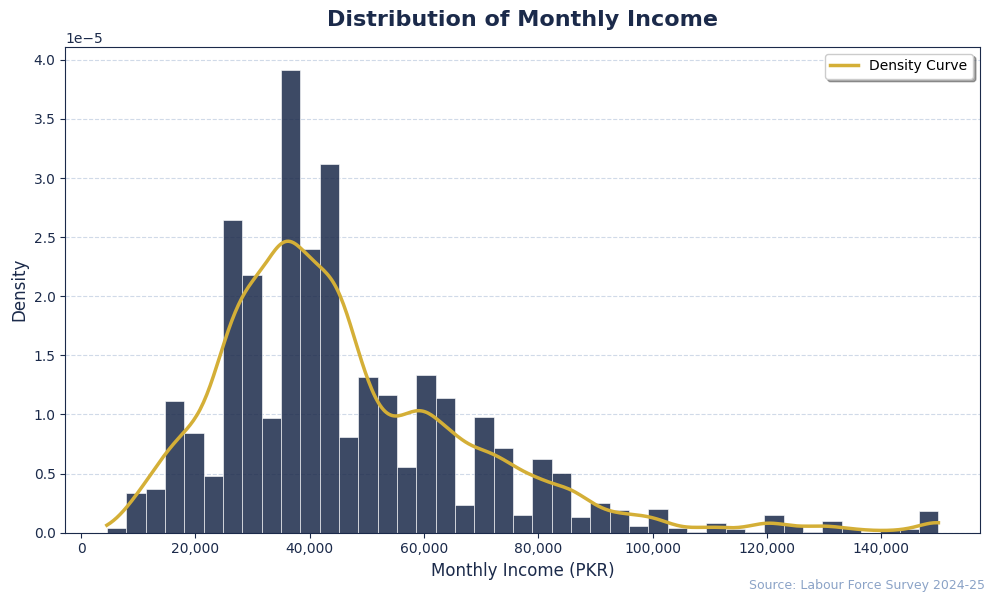

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Load data
df = pd.read_csv('/content/Mismatch_Earnings_LFS2024_25_cleaned data.csv')

# Drop outliers above p99
p99 = df['income'].quantile(0.99)
df_clean = df[df['income'] <= p99]

# Plot density histogram like Stata
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(df_clean['income'], bins=43,
        color='#1B2A4A',
        edgecolor='white',
        linewidth=0.5,
        alpha=0.85,
        density=True)

# Add kernel density curve
kde = stats.gaussian_kde(df_clean['income'].dropna())
x_range = np.linspace(df_clean['income'].min(), df_clean['income'].max(), 500)
ax.plot(x_range, kde(x_range),
        color='#D4AF37',  # Gold color for contrast
        linewidth=2.5,
        label='Density Curve')

# Titles and labels
ax.set_title('Distribution of Monthly Income',
             fontsize=16, fontweight='bold',
             color='#1B2A4A', pad=15)
ax.set_xlabel('Monthly Income (PKR)',
              fontsize=12, color='#1B2A4A')
ax.set_ylabel('Density',
              fontsize=12, color='#1B2A4A')

# Format x axis with commas
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add legend
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#8BA3C7')
ax.set_axisbelow(True)

# Background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Tick colors
ax.tick_params(colors='#1B2A4A')
for spine in ax.spines.values():
    spine.set_edgecolor('#1B2A4A')

# Source note
plt.figtext(0.99, 0.01, 'Source: Labour Force Survey 2024-25',
            ha='right', fontsize=9, color='#8BA3C7')

plt.tight_layout()
plt.savefig('histogram_income_with_curve.png', dpi=300, bbox_inches='tight')
plt.show()